<a href="https://colab.research.google.com/github/setdaygamer12/Nguy-n-c-Minh-/blob/B%C3%A0i-t%E1%BA%ADp-AI-tu%E1%BA%A7n-1/baitapAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q osmnx networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.6 MB/s eta 0:00:00


In [2]:
!pip install osmnx

In [3]:
#23.1
import folium
m = folium.Map(location=[10.7610532,106.6657831],zoom_start=13)
folium.Marker([10.7610532,106.6657831],popup="Dai hoc kinh te co so B UEH",tooltip="click vao").add_to(m)
folium.Marker([10.7712489,106.6695483],popup="Van Hanh mail",tooltip="click vao").add_to(m)
folium.Marker([10.7554425,106.6618863],popup="Benh vien dai hoc y duoc TPHCM",tooltip="click vao").add_to(m)
folium.Marker([10.7512437,106.6505975],popup="Ben xe cho lon",tooltip="click vao").add_to(m)
folium.Marker([10.7606922,106.6733144],popup="Cong vien Hoa Binh",tooltip="click vao").add_to(m)
folium.Marker([10.7722948,106.6648054],popup="Cong An quan 10",tooltip="click vao").add_to(m)
m

In [7]:
#23.2
import folium

from geopy.distance import geodesic

from geopy.geocoders import Nominatim

center="Đại học Kinh tế TP.HCM "
diemden = [
    "Chợ Bến Thành, Quận 1,",
    "Landmark 81,TP.HCM",
    "Sân bay Tân Sơn Nhất, TP.HCM",
    "Bảo tàng Chứng tích Chiến tranh,TP.HCM",
    "Bưu điện Trung tâm, TP.HCM",
    "Chợ Bình Tây, P.HCM",
    "Cầu Ánh Sao,TP.HCM",
    "Thảo Cầm Viên,TP.HCM",
    "Dinh Độc Lập,TP.HCM",
    "Nhà thờ Đức Bà,TP.HCM"
]
geolocator=Nominatim(user_agent="colab-map-demo",timeout=10)
loccentre=geolocator.geocode(center)
latlng_centre=(loccentre.latitude,loccentre.longitude)
m=folium.Map(location=latlng_centre,zoom_start=13)
folium.Marker(latlng_centre,popup=center).add_to(m)

for diachi in diemden:
  loc=geolocator.geocode(diachi)
  latlng_diachi=(loc.latitude,loc.longitude)
  distance=geodesic(latlng_centre,latlng_diachi).km
  folium.Marker(latlng_diachi,popup=f"{diachi}").add_to(m)
  folium.PolyLine([latlng_centre,latlng_diachi],color="blue",tooltip=f"cach UEH khoang {distance:.2f} km theo đường chim bay").add_to(m)
m

In [8]:
#23.3
import folium
from folium.plugins import HeatMap
m = folium.Map(location=[10.7610532,106.6657831],zoom_start=13)
Q1=[[10.8327226,106.774056]]
QGV=[[10.8278036,106.6769222]]
HeatMap(Q1,radius=20,blur=17).add_to(m)
HeatMap(QGV,radius=35,blur=15).add_to(m)
folium.Marker([10.8327226,106.774056],popup="Khu vực có khoảng 204.899 dân cư",tooltip="Quận 1").add_to(m)
folium.Marker([10.8278036,106.6769222],popup="Khu vực có khoảng 676.899 dân cư",tooltip="Quận Gò Vấp").add_to(m)
m

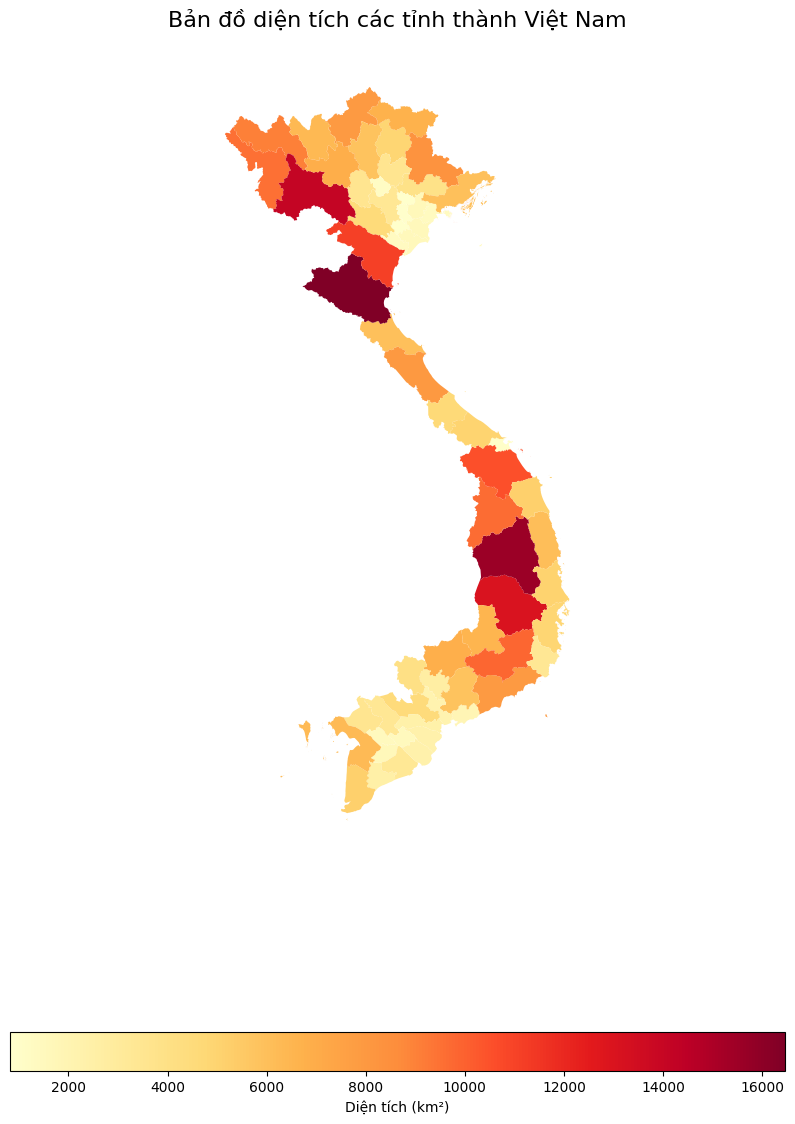

In [11]:
#23.4
import geopandas as gpd
import matplotlib.pyplot as plt
vietnam_provinces = gpd.read_file("/content/gadm41_VNM_1.json")
vietnam_provinces = vietnam_provinces.to_crs(epsg=3405) #chuyển sang tọa độ
vietnam_provinces['area_km2'] = vietnam_provinces['geometry'].area / 10**6

fig, ax = plt.subplots(1, 1, figsize=(10, 15))


vietnam_provinces.plot(column='area_km2', ax=ax, legend=True, cmap='YlOrRd',legend_kwds={'label': "Diện tích (km²)", 'orientation': "horizontal"}, linewidth=1)
plt.title("Bản đồ diện tích các tỉnh thành Việt Nam", fontsize=16)
ax.set_axis_off()

plt.show()

In [12]:
#23.5
import folium
landmark81=[10.7946108,106.7219968]
m=folium.Map(location=landmark81,zoom_start=13)
folium.Circle(landmark81, radius=1500, color='green', fill=False,tooltip="Vùng 1.5km: Đầy đủ trạm sạc Vinfast trực tiếp",fill_opacity=0.1).add_to(m)
folium.Circle(landmark81, radius=3500,color='orange',fill=False,tooltip="Vùng 3.5km: Giới hạn quy hoạch tối đa",fill_opacity=0.1).add_to(m)
folium.Circle(landmark81,radius=5000,color='red',fill=False,tooltip="Vùng 5km: Cần trạm sạc Vinfast mới tiếp ứng",fill_opacity=0.1).add_to(m)
folium.Marker(landmark81,popup="landmark81 Vincom",tooltip="click vao").add_to(m)
m

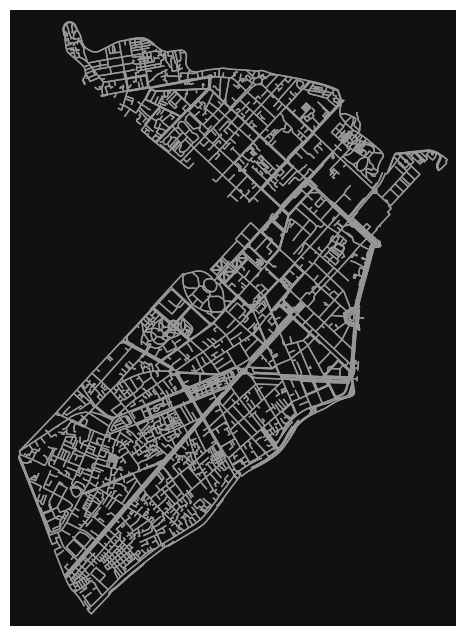

 Số lượng nút giao : 4696 nút
Số lượng đoạn đường : 13212 đoạn
Chiều dài trung bình mỗi đoạn: 39.58 mét


In [13]:
#23.6
import osmnx as ox

place = "District 1, Ho Chi Minh City"

G = ox.graph_from_place(place, network_type='walk')
fig, ax = ox.plot_graph(G, node_size=0,node_color='red')

G_proj = ox.project_graph(G)
stats = ox.basic_stats(G_proj)

print(f" Số lượng nút giao : {stats['n']} nút")
print(f"Số lượng đoạn đường : {stats['m']} đoạn")
print(f"Chiều dài trung bình mỗi đoạn: {stats['edge_length_avg']:.2f} mét")

In [14]:
#23.7
import folium
import osmnx as ox
import networkx as nx
vitri1 = [10.7725, 106.6980] #vĩ độ, kinh độ 106.6980, 10.7725
vitri2 = [10.7951405, 106.7220023] #10.7951405,106.7220023
G=ox.graph_from_point(vitri1,dist=3000,network_type='drive')
vitri1_node=ox.distance.nearest_nodes(G,vitri1[1],vitri1[0])
vitri2_node=ox.distance.nearest_nodes(G,vitri2[1],vitri2[0])
route=nx.shortest_path(G,vitri1_node,vitri2_node,weight='length')
route_coords=[(G.nodes[u]['y'],G.nodes[u]['x']) for u in route]
m=folium.Map(vitri1,zoom_start=13)
folium.Marker((vitri1[0],vitri1[1]),tooltip="vị trí 1",icon=folium.Icon(color='blue')).add_to(m)
folium.Marker((vitri2[0],vitri2[1]),tooltip="Landmark 81",icon=folium.Icon(color='red')).add_to(m)
print("dijkstra là đường chim bay")
folium.PolyLine([(vitri1[0],vitri1[1]),(vitri2[0],vitri2[1])],tooltip="dijkstra",color='green').add_to(m)
print("A* là đường đi thật")
folium.PolyLine(route_coords,tooltip="A star",color='black').add_to(m)
display(m)

dijkstra là đường chim bay
A* là đường đi thật


In [15]:
#23.8
import folium
from geopy.distance import geodesic
# tọa độ: [Kinh độ (X), Vĩ độ (Y)]
khachhang = (10.7725, 106.6980)
xe = [(10.7750, 106.7010),(10.7710, 106.6950),(10.7700, 106.7050)]
xe_ranh=[]
m = folium.Map([10.7725, 106.6980], zoom_start=15)
for i in range(len(xe)):
  distance_km=geodesic(xe[i],khachhang).km
  xe_ranh.append(distance_km)
  folium.Marker(location=xe[i],tooltip=f"Tài xế {i+1} ",icon=folium.Icon(color='blue')).add_to(m)
  print(f"xe {i+1} cách bạn khoảng {distance_km:.2f} km (theo đường chim bay)")
min_distance=min(xe_ranh)
index=xe_ranh.index(min_distance)
xe_chon=xe[index]
folium.PolyLine([khachhang,xe_chon],color='orange',weight=5,tooltip=f"cách {min_distance:.2f} km").add_to(m)
print(f"Tài xế xe {index+1} sẽ đến đón bạn trong vòng {(min_distance/15)*60:.1f} phút")
folium.Marker(khachhang,tooltip="khách hàng",icon=folium.Icon(color='red')).add_to(m)
display(m)

xe 1 cách bạn khoảng 0.43 km (theo đường chim bay)
xe 2 cách bạn khoảng 0.37 km (theo đường chim bay)
xe 3 cách bạn khoảng 0.81 km (theo đường chim bay)
Tài xế xe 2 sẽ đến đón bạn trong vòng 1.5 phút


In [17]:
#23.9
import folium
from geopy.distance import geodesic
diadiem=[(10.78, 106.71), (10.79, 106.70), (10.77, 106.68),(10.76, 106.70)]
lattong=0
lontong=0
for i in range(len(diadiem)):
  lat=diadiem[i][0]
  lon=diadiem[i][1]
  lattong += lat
  lontong += lon
  center = ((lattong/len(diadiem)),(lontong/len(diadiem)))
m=folium.Map(location=(10.79, 106.70),zoom_start=13)
folium.Marker(center,tooltip="kho hàng ở vị trí tối ưu",icon=folium.Icon(color='red')).add_to(m)
i=0
for diachi in diadiem:
  i+=1
  folium.Circle(diachi,radius=200,color='blue',fill='green',tooltip=f"trạm trung chuyển {i}").add_to(m)
display(m)

In [19]:
import folium  #23.11
from folium.plugins import HeatMap
data_points = [
    [10.816, 106.663], [10.817, 106.665], [10.815, 106.660],
    [10.805, 106.678], [10.806, 106.679], [10.804, 106.677],
    [10.825, 106.675], [10.826, 106.676], [10.824, 106.674]
]
m = folium.Map(location=[10.81, 106.67], zoom_start=14)
HeatMap(data_points, radius=22, blur=18).add_to(m)
folium.Circle(location=[10.816, 106.663], radius=500, color='red', fill=True, popup='Sân bay có lượng khách rất đông').add_to(m)
folium.Circle(location=[10.805, 106.678], radius=400, color='green', fill=True, popup='Khu ẩm thực có lượng khách ổn định').add_to(m)
folium.Circle(location=[10.825, 106.675], radius=350, color='blue', fill=True, popup='Vùng khác có lượng khách ở mức trung bình').add_to(m)
m

In [20]:
import folium #23.12
from geopy.distance import geodesic
kho = (10.776, 106.700)
khach = [(10.78, 106.71), (10.79, 106.70), (10.77, 106.68),(10.74, 106.72), (10.72, 106.70), (10.73, 106.69)]
chua_di = khach.copy() #copy lại danh sách
lo_trinh = [kho]
diem_hientai = kho
while chua_di:
    khoang_cach_ngan_nhat = 9999999
    diem_gan_nhat = None
    for k in chua_di:
        khoang_cach = geodesic(diem_hientai, k).km
        if khoang_cach < khoang_cach_ngan_nhat:
            khoang_cach_ngan_nhat = khoang_cach
            diem_gan_nhat = k
    lo_trinh.append(diem_gan_nhat)
    chua_di.remove(diem_gan_nhat)
    diem_hientai = diem_gan_nhat
lo_trinh.append(kho)
m = folium.Map(location=kho, zoom_start=13)
folium.Marker(kho, tooltip="Kho", icon=folium.Icon(color='red', icon='home')).add_to(m)
for k in khach:
    folium.Marker(k, tooltip="Khách hàng", icon=folium.Icon(color='blue')).add_to(m)
folium.PolyLine(lo_trinh, color='green',).add_to(m)
display(m)

In [18]:
import folium #23.13
from geopy.distance import geodesic
kho_A = (10.7769, 106.7009)
cua_hang_B = (10.7850, 106.7150)
vung_hoat_dong = [(10.770, 106.690), (10.790, 106.690), (10.780, 106.720)]
khoang_cach = geodesic(kho_A, cua_hang_B).km
m = folium.Map(location=kho_A, zoom_start=14)
folium.Marker(kho_A, tooltip="Kho A",icon=folium.Icon(color='green')).add_to(m)
folium.Marker(cua_hang_B, tooltip="Cửa hàng B",icon=folium.Icon(color='green')).add_to(m)
folium.PolyLine([kho_A, cua_hang_B], color="red", tooltip=f"Tuyến đường: {khoang_cach:.2f} km").add_to(m)
folium.Polygon(vung_hoat_dong, color="blue", fill=True, tooltip="Khu vực quản lý").add_to(m)
display(m)